In [18]:
import random 

OrderID = random.sample(range(1, 1000), 100)

import pandas as pd
import numpy as np


start_date = pd.to_datetime("2025-01-01")
end_date = pd.to_datetime("2025-12-31")

OrderDate = pd.to_datetime(
    np.random.randint(
        start_date.value // 10**9,
        end_date.value // 10**9,
        100
    ),
    unit="s"
).date
City = random.choices([
    "Delhi",
    "Mumbai",
    "Jaipur",
    "Bangalore",
    "Pune",
    "Chennai",
    "Hyderabad",
    "Kolkata"
], k=100)
Product=random.choices([
    "Laptop",
    "Phone",
    "Tablet",
    "Smartwatch",
    "Headphones",
    "Monitor",
    "Chair",
    "Table",
    "Sofa",
    "Printer"
],k=100)
Quantity = [random.randint(1,10) for _ in range(100)]
price = {
    "Laptop": 50000,
    "Phone": 25000,
    "Tablet": 15000,
    "Chair": 3000,
    "Table": 7000,
    "Sofa": 25000,
    "Headphones": 2000,
    "Smartwatch": 5000,
    "Printer":10000,
    "Monitor":20000
}



In [19]:


Price_List = [price[p] for p in Product]

sales = pd.DataFrame({
    "OrderID": OrderID,
    "OrderDate": OrderDate,
    "City": City,
    "Product": Product,
    "Quantity": Quantity,
    "Price": Price_List
})

sales



,OrderID,OrderDate,City,Product,Quantity,Price
0,382,2025-03-04,Chennai,Smartwatch,5,5000
1,955,2025-02-24,Mumbai,Headphones,8,2000
2,530,2025-07-29,Delhi,Smartwatch,2,5000
3,37,2025-01-23,Delhi,Phone,2,25000
4,641,2025-07-28,Pune,Sofa,7,25000
...,...,...,...,...,...,...
95,726,2025-12-10,Bangalore,Laptop,8,50000
96,448,2025-09-01,Delhi,Smartwatch,1,5000
97,388,2025-04-09,Jaipur,Table,2,7000
98,224,2025-05-25,Kolkata,Chair,3,3000


# Cheaking the value null or not

In [20]:
sales.isnull().sum()

OrderID      0
OrderDate    0
City         0
Product      0
Quantity     0
Price        0
dtype: int64

# Creating the revenue coloum

In [21]:
sales["Revenue"]=sales["Price"]*sales["Quantity"]
sales

,OrderID,OrderDate,City,Product,Quantity,Price,Revenue
0,382,2025-03-04,Chennai,Smartwatch,5,5000,25000
1,955,2025-02-24,Mumbai,Headphones,8,2000,16000
2,530,2025-07-29,Delhi,Smartwatch,2,5000,10000
3,37,2025-01-23,Delhi,Phone,2,25000,50000
4,641,2025-07-28,Pune,Sofa,7,25000,175000
...,...,...,...,...,...,...,...
95,726,2025-12-10,Bangalore,Laptop,8,50000,400000
96,448,2025-09-01,Delhi,Smartwatch,1,5000,5000
97,388,2025-04-09,Jaipur,Table,2,7000,14000
98,224,2025-05-25,Kolkata,Chair,3,3000,9000


## Highest revenue cities and highest revenue Product

In [22]:
sales.loc[sales["Revenue"].idxmax(), ["Product", "City"]]

Product     Laptop
City       Kolkata
Name: 25, dtype: str

# Month  sale

In [23]:
sales["Month"] = pd.to_datetime(sales["OrderDate"]).dt.month_name()
Monthly_sales=sales.groupby("Month")["Revenue"].sum()
Monthly_sales


Month
April         524000
August        576000
December     1220000
February      526000
January      1156000
July         1389000
June          778000
March         660000
May           453000
November      247000
October      1244000
September    1560000
Name: Revenue, dtype: int64

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# City with their Revenue

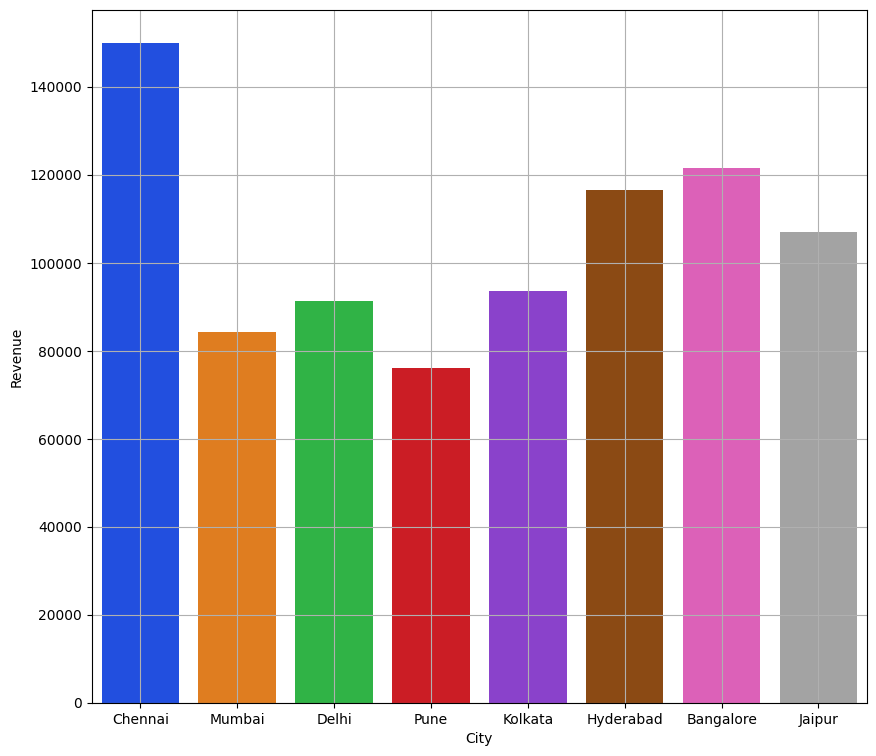

In [25]:
plt.figure(figsize=(10,9))
sns.barplot(x="City", y="Revenue", data=sales, estimator=np.mean,
             palette="bright", errorbar=None,hue="City")
plt.grid()
plt.show()


Insight:
Bangalore generated the highest revenue.
Jaipur generated the lowest revenue.
Marketing efforts should focus on Jaipur.

# Product and their Qunantity

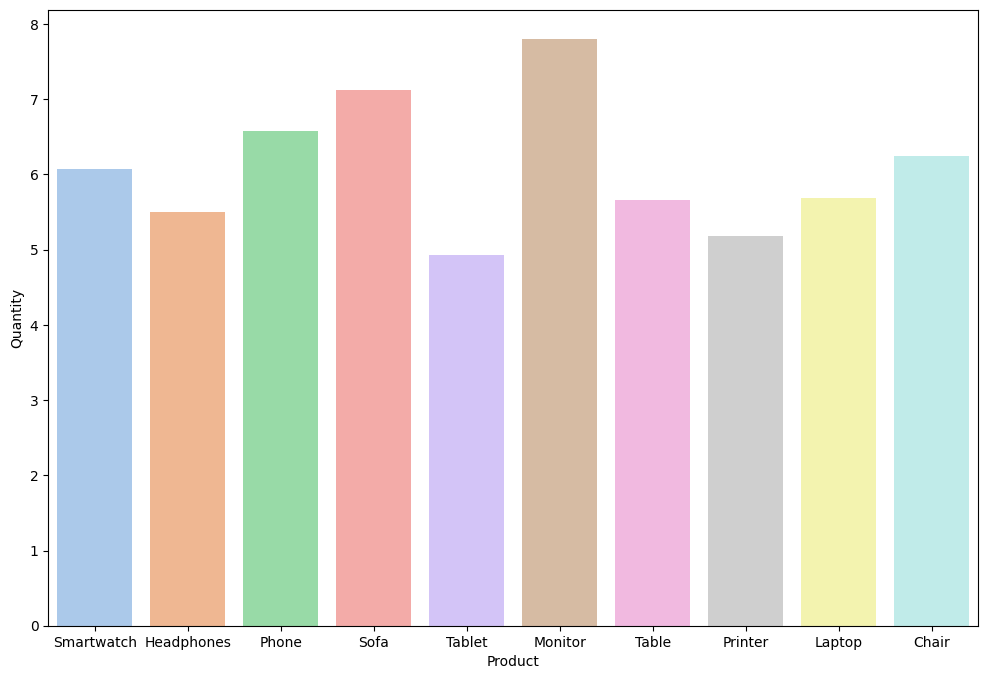

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(x="Product",y="Quantity",hue="Product",
            data=sales,palette="pastel",errorbar=None)# Adding the hue for prevent form the Palette error
plt.show()


Observation

Laptop generated the highest sales.
Chair generated the lowest sales.

Insight

Customers prefer premium electronic products.
Furniture products contribute less revenue.

Recommendation

Maintain higher stock levels for laptops.
Review pricing and marketing strategy for furniture.

# Monthly Revenue

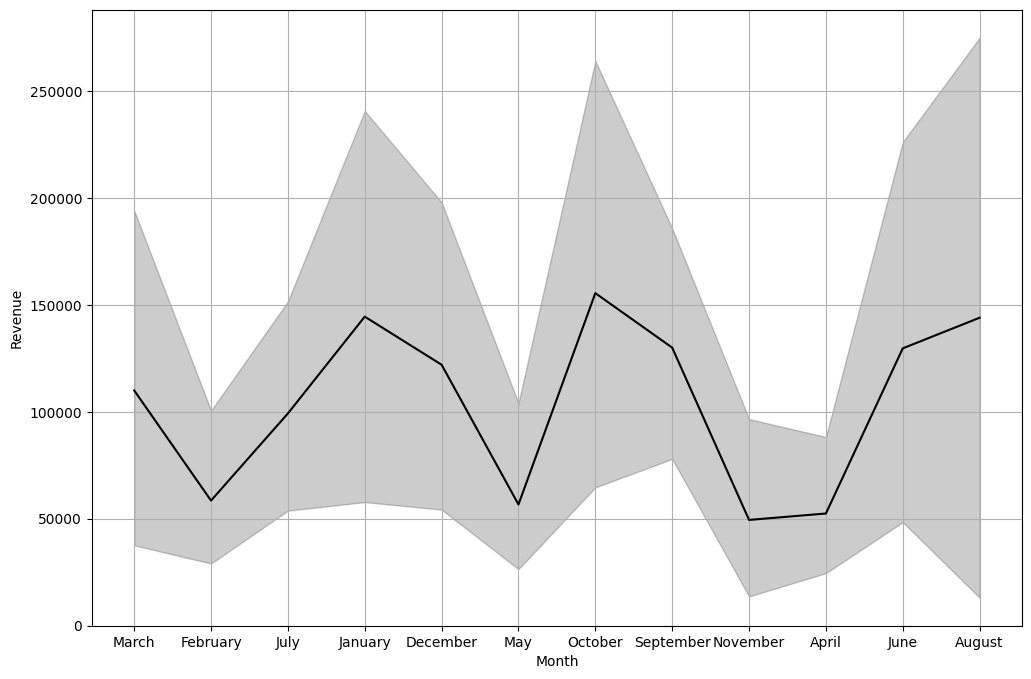

In [27]:
plt.figure(figsize=(12,8))
sns.lineplot(data=sales,x="Month",y="Revenue",color="black" ,markers="*")
plt.grid()

Observation

Revenue peaked in october.
Revenue was lowest in June.

Insight

Sales fluctuate throughout the year.
Demand increases during certain seasons.

Recommendation

Increase inventory before peak months.
Run promotional campaigns during slow months.

# Revenue Distribution according Qunantity

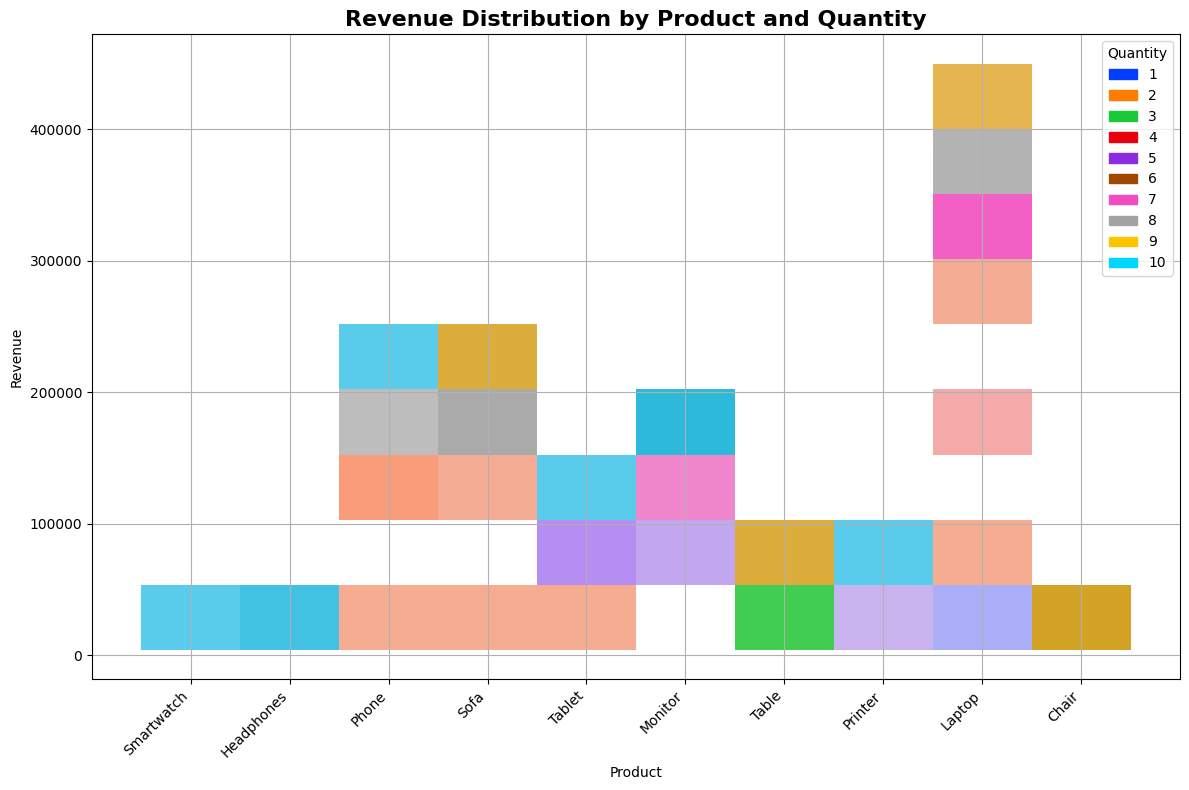

In [28]:
plt.figure(figsize=(12,8))
sns.histplot(x="Product", y="Revenue", hue="Quantity", data=sales, palette="bright", multiple="fill")
plt.title("Revenue Distribution by Product and Quantity", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid()
plt.show()

Observation

Most orders fall within a specific revenue range.
A few orders have very high revenue.

Insight

The business receives many medium-value orders.
High-value orders significantly contribute to total revenue.

Recommendation

Focus on upselling to increase average order value.
Identify customers responsible for large purchases.

#  Product-wise Revenue Distribution

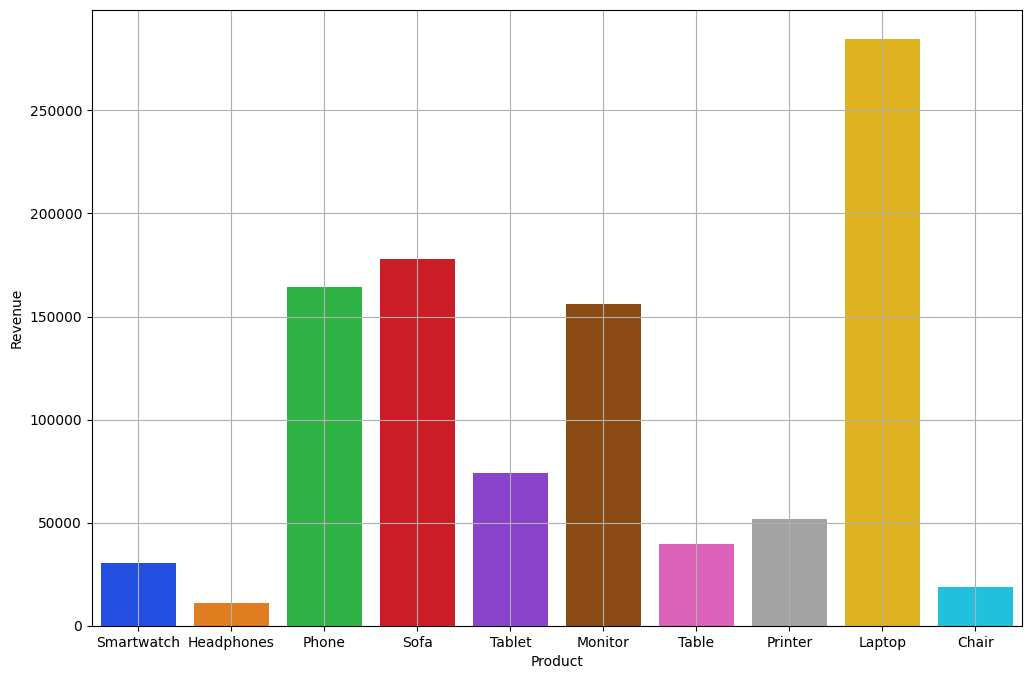

In [29]:
plt.figure(figsize=(12,8))
sns.barplot(x="Product",y="Revenue",hue="Product",data=sales,palette="bright",errorbar=None)
plt.grid()
plt.show()

Observation

Laptop revenue shows a larger spread than other products.
Some products have outliers.

Insight

Revenue varies greatly across products.
Certain products generate occasional large sales.

Recommendation

Investigate products with high variability.
Ensure stock availability for products with large spikes.

# Quantity vs Revenue

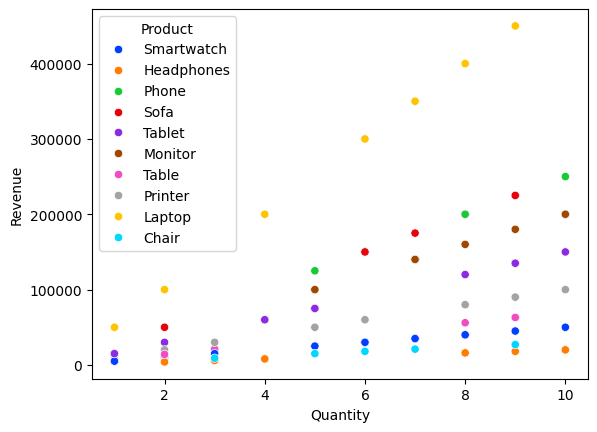

In [30]:
sns.scatterplot(x="Quantity",y="Revenue",hue="Product",data=sales,palette="bright",legend="brief")
plt.show()

Observation

Revenue distribution differs across cities.
Some cities show more revenue variation.

Insight

Customer purchasing behavior varies by region.

Recommendation

Develop city-specific marketing strategies.
Allocate inventory based on local demand.

# Correlation Analysis

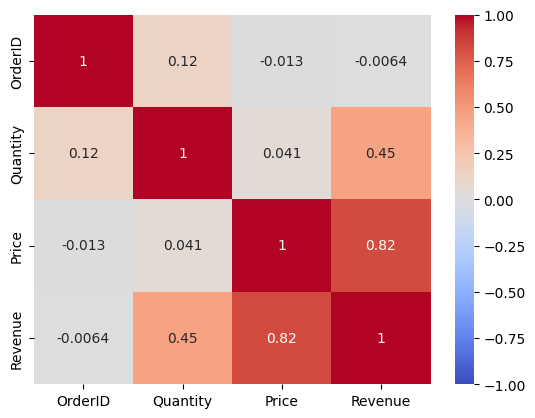

In [31]:
sns.heatmap(
    sales.select_dtypes(include=np.number).corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
plt.show()

Observation

Revenue generally increases as quantity increases.
Some low-quantity orders still generate high revenue.

Insight

Expensive products can generate high revenue even with low sales volume.

Recommendation

Focus on promoting high-margin products.
Do not rely solely on quantity sold as a performance metric.

# Complete info on the basis of the product

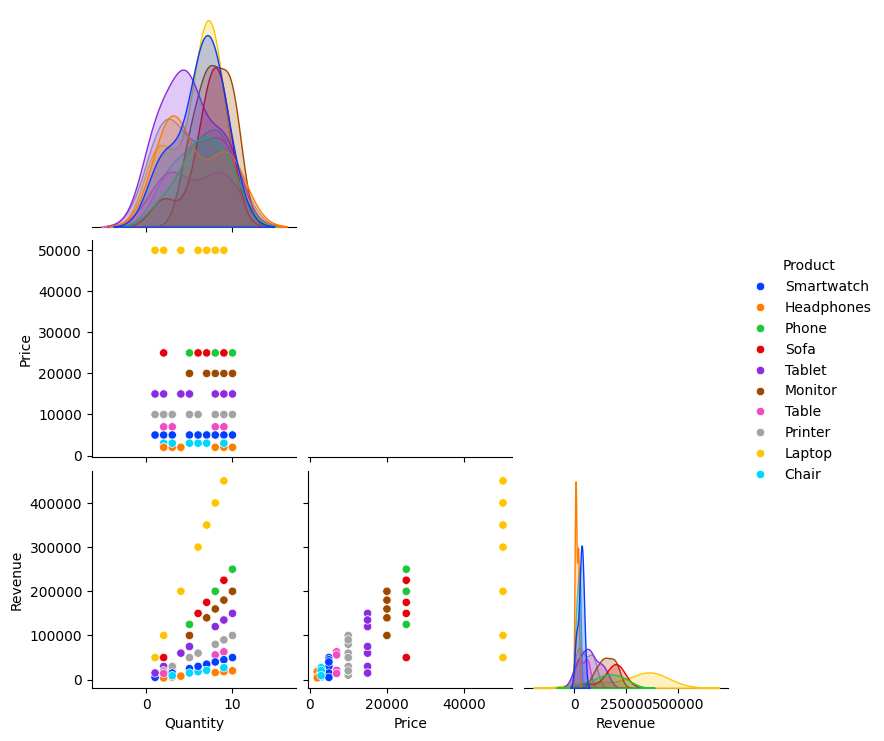

In [32]:

sns.pairplot(sales, vars=["Quantity","Price","Revenue"],
              hue="Product",palette="bright", corner=True )
plt.show()

# Revenue according the Product share

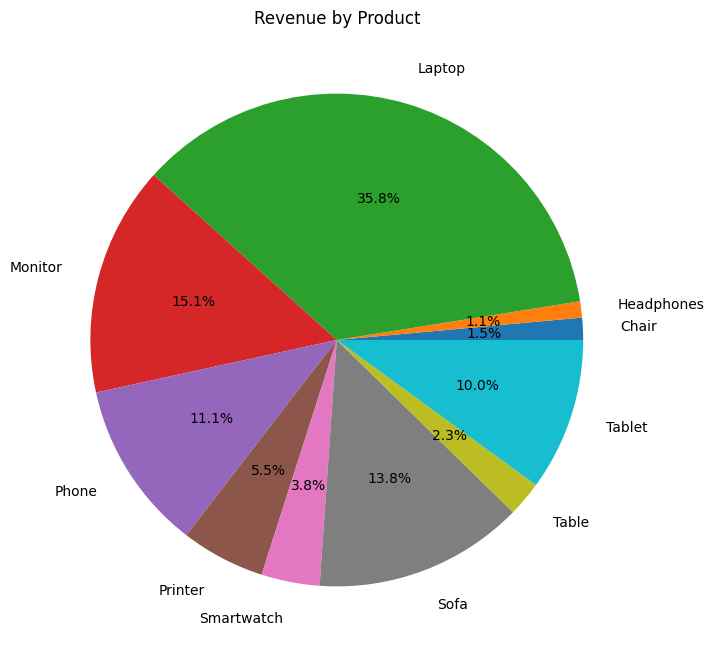

In [33]:
product_revenue = sales.groupby("Product")["Revenue"].sum()

plt.figure(figsize=(10,8))

plt.pie(
    product_revenue,
    labels=product_revenue.index,
    autopct='%1.1f%%',
    labeldistance=1.15,
    pctdistance=0.6
)

plt.title("Revenue by Product")
plt.show()

Observation

Revenue has a strong positive correlation with Price.
Revenue has a moderate positive correlation with Quantity.

Insight

Product price influences revenue more than sales volume.

Recommendation

Optimize product pricing strategies.
Promote premium products where possible.

Key Findings

• Bangalore generated the highest revenue.

• Hyderabad generated the lowest revenue.

• Laptops were the top-performing product.

• Revenue peaked during the last quarter of the year.

• Product demand varied significantly across cities and months.

• Price had a stronger impact on revenue than quantity sold.


Business Recommendations

• Increase inventory for top-performing products.

• Focus marketing efforts on low-performing cities.

• Prepare inventory in advance for seasonal demand spikes.

• Use regional product preferences for targeted promotions.
